## Initialisation

In [1]:
using LibFEM
# Units system mm/tonne/s/K
# ===============================================================================
# 2D FRAME
# ===============================================================================
#(2)-----(3)
#  \      /
#   \    /
#    \  / 
#     \/  
#    / \  
#   /   \ 
#(1)----(4)
# ===============================================================================
# The element used here is a linear 2D straight truss with constant cross section
# The degrees of freedom are the u & v displacements
# ===============================================================================
# PARAMETERS
const L = 1000. # length in mm
const A = 100. # cross-sectional area in mm^2
const E = 210000. # modulus of elasticity in Mpa [aluminium]
const FM = 5000. # force modulus in N
# ===============================================PRE-PROCESSING==================
# DEFINING AND DISCRETIZING[MESHING] THE STRUCTURE
# connectivity table
# elt|node_i|node_j
# 1|1|3
# 2|2|3
# 3|2|4
# grid()
X1pos = 0.; Y1pos = 0.
X2pos = 0.; Y2pos = L
X3pos = L; Y3pos = L
X4pos = L; Y4pos = 0
# lengths
L1 = d2_truss_elementlength(X1pos,Y1pos,X3pos,Y3pos) # length of element 1
L2 = d2_truss_elementlength(X2pos,Y2pos,X3pos,Y3pos) # length of element 2
L3 = d2_truss_elementlength(X2pos,Y2pos,X4pos,Y4pos) # length of element 3

# APPLYING GEOMETRIC&MATERIAL PROPERTIES AND TYPE OF ELEMENTS
A1 = sqrt(2) * A # cross-sectional area of element 1
A2 = A # cross-sectional area of element 2
A3 = sqrt(2) * A # cross-sectional area of element 3
E1 = E # material of element 1
E2 = E # material of element 2
E3 = E; # material of element 3

## writing-defining element stiffness matrices


In [2]:
K1 = d2_truss_elementstiffness(E1,A1,L1,45.)

4×4 Matrix{Float64}:
  10500.0   10500.0  -10500.0  -10500.0
  10500.0   10500.0  -10500.0  -10500.0
 -10500.0  -10500.0   10500.0   10500.0
 -10500.0  -10500.0   10500.0   10500.0

In [3]:
K2 = d2_truss_elementstiffness(E2,A2,L2,0.)

4×4 Matrix{Float64}:
  21000.0   0.0  -21000.0  -0.0
      0.0   0.0      -0.0  -0.0
 -21000.0  -0.0   21000.0   0.0
     -0.0  -0.0       0.0   0.0

In [4]:
K3 = d2_truss_elementstiffness(E3,A3,L3,-45.)

4×4 Matrix{Float64}:
  10500.0  -10500.0  -10500.0   10500.0
 -10500.0   10500.0   10500.0  -10500.0
 -10500.0   10500.0   10500.0  -10500.0
  10500.0  -10500.0  -10500.0   10500.0

### ASSEMBLING THE GLOBAL STIFFNESS MATRIX

In [5]:
K = zeros(8, 8);K1P = zeros(8, 8)
# matrices positionning
K1P = d2_truss_assemble(K,K1,1,3)

8×8 Matrix{Float64}:
  10500.0   10500.0  0.0  0.0  -10500.0  -10500.0  0.0  0.0
  10500.0   10500.0  0.0  0.0  -10500.0  -10500.0  0.0  0.0
      0.0       0.0  0.0  0.0       0.0       0.0  0.0  0.0
      0.0       0.0  0.0  0.0       0.0       0.0  0.0  0.0
 -10500.0  -10500.0  0.0  0.0   10500.0   10500.0  0.0  0.0
 -10500.0  -10500.0  0.0  0.0   10500.0   10500.0  0.0  0.0
      0.0       0.0  0.0  0.0       0.0       0.0  0.0  0.0
      0.0       0.0  0.0  0.0       0.0       0.0  0.0  0.0

In [6]:
K = zeros(8, 8);K2P = zeros(8, 8)
K2P = d2_truss_assemble(K,K2,2,3)

8×8 Matrix{Float64}:
 0.0  0.0       0.0  0.0       0.0  0.0  0.0  0.0
 0.0  0.0       0.0  0.0       0.0  0.0  0.0  0.0
 0.0  0.0   21000.0  0.0  -21000.0  0.0  0.0  0.0
 0.0  0.0       0.0  0.0       0.0  0.0  0.0  0.0
 0.0  0.0  -21000.0  0.0   21000.0  0.0  0.0  0.0
 0.0  0.0       0.0  0.0       0.0  0.0  0.0  0.0
 0.0  0.0       0.0  0.0       0.0  0.0  0.0  0.0
 0.0  0.0       0.0  0.0       0.0  0.0  0.0  0.0

In [7]:
K = zeros(8, 8);K3P = zeros(8, 8)
K3P = d2_truss_assemble(K,K3,2,4)

8×8 Matrix{Float64}:
 0.0  0.0       0.0       0.0  0.0  0.0       0.0       0.0
 0.0  0.0       0.0       0.0  0.0  0.0       0.0       0.0
 0.0  0.0   10500.0  -10500.0  0.0  0.0  -10500.0   10500.0
 0.0  0.0  -10500.0   10500.0  0.0  0.0   10500.0  -10500.0
 0.0  0.0       0.0       0.0  0.0  0.0       0.0       0.0
 0.0  0.0       0.0       0.0  0.0  0.0       0.0       0.0
 0.0  0.0  -10500.0   10500.0  0.0  0.0   10500.0  -10500.0
 0.0  0.0   10500.0  -10500.0  0.0  0.0  -10500.0   10500.0

In [8]:
# assembling
K = K1P + K2P + K3P

8×8 Matrix{Float64}:
  10500.0   10500.0       0.0       0.0  …  -10500.0       0.0       0.0
  10500.0   10500.0       0.0       0.0     -10500.0       0.0       0.0
      0.0       0.0   31500.0  -10500.0          0.0  -10500.0   10500.0
      0.0       0.0  -10500.0   10500.0          0.0   10500.0  -10500.0
 -10500.0  -10500.0  -21000.0       0.0      10500.0       0.0       0.0
 -10500.0  -10500.0       0.0       0.0  …   10500.0       0.0       0.0
      0.0       0.0  -10500.0   10500.0          0.0   10500.0  -10500.0
      0.0       0.0   10500.0  -10500.0          0.0  -10500.0   10500.0

In [9]:
# SOLVING DISPACEMENT EQUATIONS
# extracting displacement submatrix via index vector
K_s = K[5:6,5:6]
# setting-up the force subvector by applying Load & Boundary Conditions [LBC]]
F_s = [0., -FM]
# solving by gaussian elimination
U_s = K_s \ F_s

2-element Vector{Float64}:
  0.2380952380952382
 -0.7142857142857145

In [10]:
# SOLVING FORCE EQUATIONS
# setting-up the global nodal displacement vector
U = [0, 0, 0, 0, U_s[1], U_s[2], 0, 0]

8-element Vector{Float64}:
  0.0
  0.0
  0.0
  0.0
  0.2380952380952382
 -0.7142857142857145
  0.0
  0.0

In [11]:
# COMPUTING 
# writing the loading vector
F = K * U

8-element Vector{Float64}:
  5000.000000000002
  5000.0
 -5000.000000000002
     0.0
     0.0
 -5000.0
     0.0
     0.0

### COMPUTING STRAINS, INTERNAL FORCES, STRESSES

In [12]:
# writing the element nodal displacement vectors
U1 = [U[1], U[2], U[5], U[6]]
U2 = [U[3], U[4], U[5], U[6]]
U3 = [U[3], U[4], U[7], U[8]];

In [13]:
ϵ1 = d2_truss_elementstrain(L1,45.,U1)

1-element Vector{Float64}:
 -0.0002380952380952381

In [14]:
ϵ2 = d2_truss_elementstrain(L2,0.,U2)

1-element Vector{Float64}:
 0.0002380952380952382

In [15]:
ϵ3 = d2_truss_elementstrain(L3,-45.,U3)

1-element Vector{Float64}:
 0.0

In [16]:
f1 = d2_truss_elementforce(E1,A1,L1,45.,U1)

1-element Vector{Float64}:
 -7071.067811865476

In [17]:
f2 = d2_truss_elementforce(E2,A2,L2,0.,U2)

1-element Vector{Float64}:
 5000.000000000002

In [18]:
f3 = d2_truss_elementforce(E3,A3,L3,-45.,U3)

1-element Vector{Float64}:
 0.0

In [19]:
σ1 = d2_truss_elementstress(E1,L1,45.,U1)

1-element Vector{Float64}:
 -50.000000000000014

In [20]:
σ2 = d2_truss_elementstress(E2,L2,0.,U2)

1-element Vector{Float64}:
 50.00000000000002

In [21]:
σ3 = d2_truss_elementstress(E3,L3,-45.,U3)

1-element Vector{Float64}:
 0.0

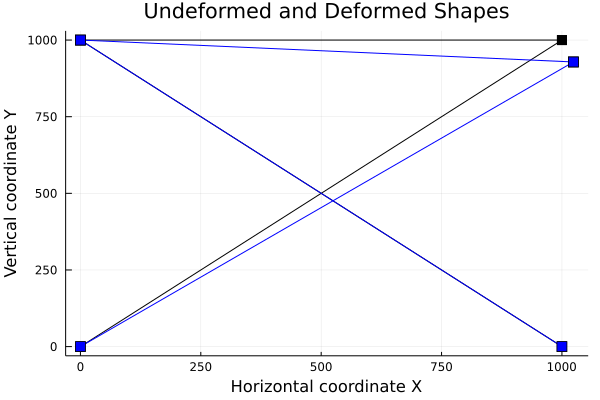

In [22]:
using Plots
Xini = [X1pos, X3pos]
Yini = [Y1pos, Y3pos]
plot(Xini,Yini,label=false,marker=5,shape=:sq,color=:black)
Xini = [X2pos, X3pos]
Yini = [Y2pos, Y3pos]
plot!(Xini,Yini,label=false,marker=5, shape=:sq, color=:black)
Xini = [X2pos, X4pos]
Yini = [Y2pos, Y4pos]
plot!(Xini,Yini,label=false,marker=5, shape=:sq, color=:black)
fampl = 100
Xdef = [(X1pos + fampl * U[1]), (X3pos + fampl * U[5])]
Ydef = [(Y1pos + fampl * U[2]), (Y3pos + fampl * U[6])]
plot!(Xdef,Ydef,label=false,marker=5,shape=:sq,color=:blue)
Xdef = [(X2pos + fampl * U[3]), (X3pos + fampl * U[5])]
Ydef = [(Y2pos + fampl * U[4]), (Y3pos + fampl * U[6])]
plot!(Xdef,Ydef,label=false,marker=5,shape=:sq,color=:blue)
Xdef = [(X2pos + fampl * U[3]), (X4pos + fampl * U[7])]
Ydef = [(Y2pos + fampl * U[4]), (Y4pos + fampl * U[8])]
plot!(Xdef,Ydef,label=false,title="Undeformed and Deformed Shapes",
xlabel="Horizontal coordinate X",
ylabel="Vertical coordinate Y",marker=5,shape=:sq,color=:blue)